# Linear discriminant analysis for concrete strength classification

In previous notebooks, we used a dataset containing concrete mix design variables together with the corresponding compressive strength values.

In this notebook, rather than predicting the compressive strength from a regression perspective, we discretize the target variable into three strength classes:
- Low strength: $f_c < 25\ \text{MPa}$
- Medium strength: $25 \leq f_c \leq 40\ \text{MPa}$
- High strength: $f_c > 40\ \text{MPa}$
  
We will then reformulate the original regression problem as a multiclass classification problem, and use linear discriminant analysis (LDA) to investigate whether Gaussian class models can separate the three concrete classes from the mix design predictors.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

### Load data

The dataset contains:
- Input variables describing the concrete composition
- One target variable corresponding to the concrete compressive strength

In [2]:
# Load data from Excel
file_path = "../Data/Concrete/Concrete.xls"
df = pd.read_excel(file_path)
# The dataset is stored in Excel format (.xls).
# Pandas requires the 'xlrd' package to read this format.
# If you get an error, install it via: pip install xlrd.

# Display the first rows of the dataset
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [3]:
# In this dataset, the last column is the concrete compressive strength target
X = df.iloc[1:, :-1].values # All columns except last → input features
y = df.iloc[1:, -1].values # Last column → target

N, d = X.shape

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print(f"Number of samples: {N}")
print(f"Number of input features: {d}")

Input shape: (1029, 8)
Target shape: (1029,)
Number of samples: 1029
Number of input features: 8


### Convert compressive strength into strength classes

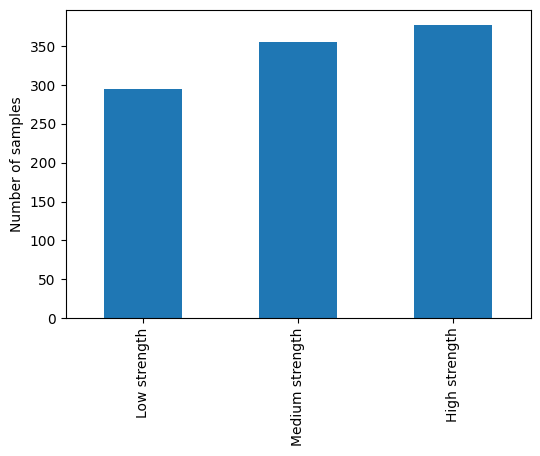

In [4]:
# Strength intervals (MPa)
bins = [0, 25, 40, np.inf]

class_names = [
    "Low strength",
    "Medium strength",
    "High strength",]

y_class = pd.cut(y,bins=bins,labels=class_names)

plt.figure(figsize=(6,4))
y_class.value_counts().sort_index().plot.bar()

plt.ylabel("Number of samples")

plt.show()

### Split and normalize the data

LDA estimates covariance matrices, variables should therefore have comparable scales.

- Split using 80% train and 20% test
- Compute normalization statistics from training data
- Consistently apply normalization to the test data

In [5]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=4, stratify=y_class)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train the LDA model

LDA provides a probabilistic classifier that assumes Gaussian-distributed features with a common covariance matrix across the classes.

In [6]:
lda = LinearDiscriminantAnalysis()

lda.fit(X_train_scaled, y_train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


### Prediction and visualization

The performance of a classifier can be evaluated by comparing its predictions with the ground-truth labels. A convenient way to summarize the classification results is with a confusion matrix, which reports the number of correctly and incorrectly classified samples.

The confusion matrix is often complemented by the accuracy metric, which measures the proportion of correctly classified samples.

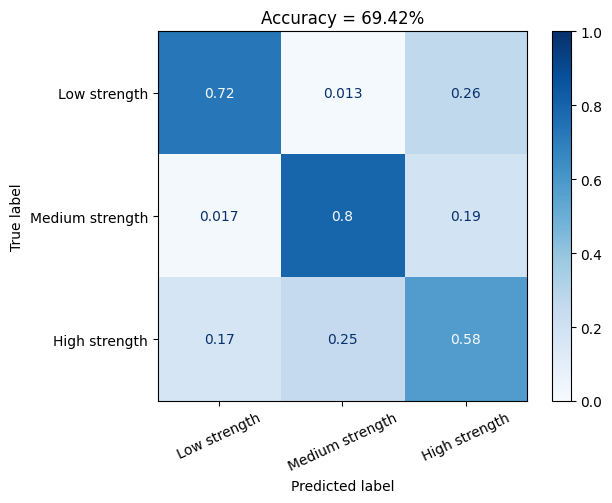

In [7]:
y_pred = lda.predict(X_test_scaled)
accuracy = accuracy_score(y_test,y_pred)

cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low strength", "Medium strength", "High strength"])
disp.plot(cmap='Blues', xticks_rotation=25)
disp.im_.set_clim(0, 1)
plt.title(f"Accuracy = {accuracy:.2%}")
plt.show()

### Posterior probabilities

We can inspect the posterior probabilities that LDA assigns to each class for every testing instance. These probabilities quantify the model's confidence that a given sample belongs to each of the three concrete strength classes.

In [8]:
probabilities = lda.predict_proba(X_test_scaled)

pd.DataFrame(
    probabilities[:10], # Display only the first ten instances
    columns=class_names
)

,Low strength,Medium strength,High strength
0,0.833895,0.012159,0.153946
1,0.211697,0.213453,0.574850
2,0.189872,0.225248,0.584880
3,0.140188,0.281281,0.578531
4,0.229181,0.247573,0.523246
5,0.035449,0.567346,0.397205
6,0.457884,0.087268,0.454848
7,0.010993,0.770233,0.218773
8,0.019186,0.653415,0.327400
9,0.032100,0.634893,0.333007
